In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import gridspec
import MATS

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")


If using the self broadening term, then consider explicitly labeling the broadener (ie in an oxygen spectra use 'O2' instead of self).  This may avoid confusion in multiple species fits. 


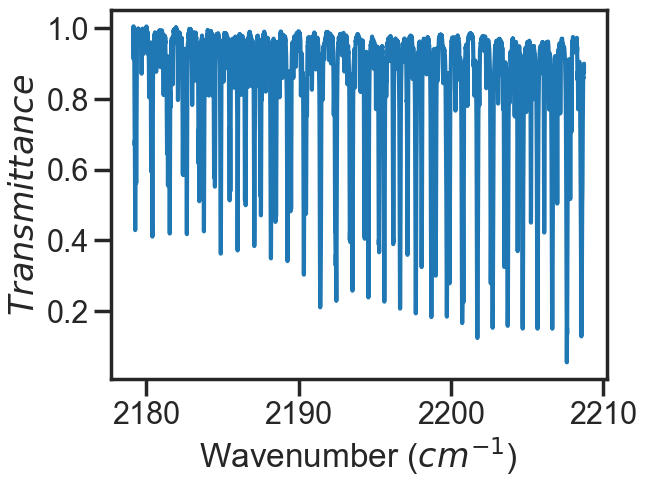

2179.136478 2208.736703 0.0050824562156593645


In [12]:
#Experimental Spectrum

pathlength = 6.985 #cm
#ILS
lorentz = 133.56 #MHz
sinc2 = 330.83 # MHz
gauss_decay = 660.32 #MHz
convolved = 891.94 #MHz

#Simulation/Model Details
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-24 #intensities must be above this value for the line to be fit
PARAM_LINELIST = pd.read_csv('MIR_N2O_Linelist.csv')

# Experimental Spectrum Details
transmittance_column = 'Tranmission'
wavenumber_column = 'Wavenumber (cm-1)' 
pressure_column = 'Pressure (Torr)'
temperature_column = 'Temperature (C)'

spec_1 =  MATS.Spectrum('MIR_N2O_spectra', molefraction = { 4 :1}, diluent = 'self',
                        input_freq = False, input_tau = False, 
                        frequency_column = wavenumber_column, tau_column = transmittance_column, 
                        temperature_column = temperature_column, pressure_column = pressure_column, 
                        baseline_order = 1, low_OD_regime = False, transmittance_space = True, pathlength = pathlength)


spec_1.plot_wave_alpha()
print (spec_1.wavenumber.min(), spec_1.wavenumber.max(), (spec_1.wavenumber.max()-spec_1.wavenumber.min())/len(spec_1.wavenumber))

You are using the 'self' term, consider explicitly labeling the broadener (ie in an oxygen spectra use 'O2' instead of 'self').  This may avoid confusion in multiple species fits. For single species fits it should not matter.
Double check that you did not include the equivalent of the self term explicitly (ie in an oxygen spectra having both 'O2' and 'self').


C:\Users\ema3\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3420: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
C:\Users\ema3\Anaconda3\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


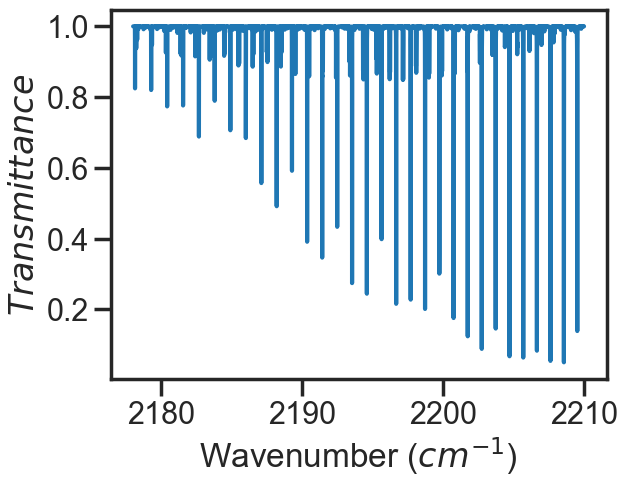

In [22]:
#Simulate Spectrum to Test Functionality


spec_2 = MATS.simulate_spectrum(PARAM_LINELIST,
                        wave_min=2178, wave_max= 2210, wave_space=0.005,
                        SNR = None, temperature = 22.85, pressure = 10,
                        wing_wavenumbers = 25, wing_method = 'wing_wavenumbers', filename = '10torr_simulated_spectra', molefraction = { 4 :1}, 
                        diluent = 'self', low_OD_regime = False, transmittance_space = True, pathlength = pathlength/100)
spec_2.plot_wave_alpha()